<a href="https://colab.research.google.com/github/Mat9408/An-lisedeDados_Distribuicao_de_Encomendas_no_DF/blob/main/M%C3%B3dulo_16_1%C2%BA_Projeto_Parte_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loggi: Análise de distribuição de encomendas pelo Distrito Federal

###Resumo: Exploração e avaliação sobre os dados disponibilizados pela empresa Loggi com objetivo de encontrar possíveis soluções para realizar a distribuição de encomendas pela região do Distrito Federal da melhor forma possível.

###Importação dos Pacotes e Bibliotecas

In [ ]:
import json
import pandas as pd
import seaborn as sns

###Exploração de Dados

In [ ]:
!wget -q "https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/deliveries.json" -O deliveries.json

In [ ]:
with open('deliveries.json', mode= 'r', encoding= 'utf8') as file:
  data = json.load(file)

In [ ]:
len(data)

199

In [ ]:
# Exemplo: Primeira instância de entrega:

example= data[0]

In [ ]:
# Identificando as chaves do dicionário

print(example.keys())

dict_keys(['name', 'region', 'origin', 'vehicle_capacity', 'deliveries'])


In [ ]:
# Identificando a região de entregas (Brasília)

example['name']

'cvrp-2-df-33'

In [ ]:
# Identificando o hub de distribuição

example['region']

'df-2'

In [ ]:
# Identificando o endereço completo do hub

# example['origin']

In [ ]:
# Identificando a latitude do endereço do hub de distribuição

example['origin']['lat']

-15.83814451122274

In [ ]:
# Identificando a longitude do endereço do hub de distribuição

example['origin']['lng']

-48.05498915846707

In [ ]:
# Identificando a capacidade máxima de entrega dos veículos

example['vehicle_capacity']

180

In [ ]:
# Identificando todos os dados da primeira entrega da lista

# exemple['deliveries'][0]

In [ ]:
# Identificando o ID da primeira entrega da lista (0)

example['deliveries'][0]['id']

'313483a19d2f8d65cd5024c8d215cfbd'

###Wrangling

In [ ]:
deliveries_df= pd.DataFrame(data)

In [ ]:
deliveries_df.head()

,name,region,origin,vehicle_capacity,deliveries
0,cvrp-2-df-33,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p..."
1,cvrp-2-df-73,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po..."
2,cvrp-2-df-20,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p..."
3,cvrp-1-df-71,df-1,"{'lng': -47.89366206897872, 'lat': -15.8051175...",180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p..."
4,cvrp-2-df-87,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p..."


- Atenção na coluna origin

Repare que a coluna origin contém dados *nested* ou *aninhados* na estrutura JSON. Vamos normalizar a coluna com uma operação conhecida como *flatten* ou achatamento que transforma cada chave do JSON em uma nova coluna:

In [ ]:
hub_origin_df= pd.json_normalize(deliveries_df['origin'])
hub_origin_df.head()

,lng,lat
0,-48.054989,-15.838145
1,-48.054989,-15.838145
2,-48.054989,-15.838145
3,-47.893662,-15.805118
4,-48.054989,-15.838145


Com os dados achatados, vamos juntá-los ao conjunto de dados principal

In [ ]:
deliveries_df= pd.merge(left= deliveries_df, right= hub_origin_df, how= 'inner', left_index= True, right_index= True)
deliveries_df.head()

,name,region,origin,vehicle_capacity,deliveries,lng,lat
0,cvrp-2-df-33,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p...",-48.054989,-15.838145
1,cvrp-2-df-73,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po...",-48.054989,-15.838145
2,cvrp-2-df-20,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p...",-48.054989,-15.838145
3,cvrp-1-df-71,df-1,"{'lng': -47.89366206897872, 'lat': -15.8051175...",180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p...",-47.893662,-15.805118
4,cvrp-2-df-87,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p...",-48.054989,-15.838145


In [ ]:
deliveries_df= deliveries_df.drop("origin", axis= 1)
deliveries_df= deliveries_df[["name", "region", "lng", "lat", "vehicle_capacity", "deliveries"]]
deliveries_df.head()

,name,region,lng,lat,vehicle_capacity,deliveries
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p..."
1,cvrp-2-df-73,df-2,-48.054989,-15.838145,180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po..."
2,cvrp-2-df-20,df-2,-48.054989,-15.838145,180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p..."
3,cvrp-1-df-71,df-1,-47.893662,-15.805118,180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p..."
4,cvrp-2-df-87,df-2,-48.054989,-15.838145,180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p..."


In [ ]:
deliveries_df.rename(columns={'lng': 'hub_lng', 'lat': 'hub_lat'}, inplace= True)
deliveries_df.head()

,name,region,hub_lng,hub_lat,vehicle_capacity,deliveries
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p..."
1,cvrp-2-df-73,df-2,-48.054989,-15.838145,180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po..."
2,cvrp-2-df-20,df-2,-48.054989,-15.838145,180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p..."
3,cvrp-1-df-71,df-1,-47.893662,-15.805118,180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p..."
4,cvrp-2-df-87,df-2,-48.054989,-15.838145,180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p..."


- Coluna: deliveries

Repara que a coluna *deliveries* contem dados uma lista de dados *nested* ou aninhados na estrutura JSON. Vamos normalizar a coluna com uma operação conhecida como explode ou explosão que transforma cada elemento da lista em uma linha. Por fim, faremos os *flatten* ou achatamento do resultado coluna.

In [ ]:
deliveries_exploded_df= deliveries_df[['deliveries']].explode('deliveries')
deliveries_exploded_df.head()

,deliveries
0,"{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'po..."
0,"{'id': '320c94b17aa685c939b3f3244c3099de', 'po..."
0,"{'id': '3663b42f4b8decb33059febaba46d5c8', 'po..."
0,"{'id': 'e11ab58363c38d6abc90d5fba87b7d7', 'poi..."
0,"{'id': '54cb45b7bbbd4e34e7150900f92d7f4b', 'po..."


In [ ]:
deliveries_normalized_df = pd.concat([
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['size'])).rename(columns= {'deliveries': 'delivery_size'}),
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['point']['lng'])).rename(columns= {'deliveries': 'delivery_lng'}),
    pd.DataFrame(deliveries_exploded_df['deliveries'].apply(lambda record: record['point']['lat'])).rename(columns= {'deliveries': 'delivery_lat'}),], axis= 1)
deliveries_normalized_df.head()

,delivery_size,delivery_lng,delivery_lat
0,9,-48.116189,-15.848929
0,2,-48.118195,-15.850772
0,1,-48.112483,-15.847871
0,2,-48.118023,-15.846471
0,7,-48.114898,-15.858055


Com os dados explodidos, vamos normalizá-los para combiná-los ao conjunto de dados principal:

In [ ]:
len(deliveries_df)

199

In [ ]:
len(deliveries_exploded_df)

636149

In [ ]:
deliveries_df = deliveries_df.drop('deliveries', axis= 1)
deliveries_df = pd.merge(left= deliveries_df,right= deliveries_normalized_df, how= 'right', left_index= True, right_index= True)
deliveries_df.reset_index(inplace= True, drop= True)
deliveries_df.head()

,name,region,hub_lng,hub_lat,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,7,-48.114898,-15.858055


In [ ]:
len(deliveries_df)

636149

Com os dados em mãos, vamos conhecer um pouco melhor a estrutura do nosso conjunto de dados.

###Estrutura

In [ ]:
# Verificar a quantidade de linhas e colunas

deliveries_df.shape

(636149, 8)

In [ ]:
# Verificar as colunas presentes no dataframe

deliveries_df.columns

Index(['name', 'region', 'hub_lng', 'hub_lat', 'vehicle_capacity',
       'delivery_size', 'delivery_lng', 'delivery_lat'],
      dtype='object')

In [ ]:
# Verificar informações de indexação do Dataframe

deliveries_df.index

RangeIndex(start=0, stop=636149, step=1)

In [ ]:
# Verificar informações gerais sobre  dataframe

deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636149 entries, 0 to 636148
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              636149 non-null  object 
 1   region            636149 non-null  object 
 2   hub_lng           636149 non-null  float64
 3   hub_lat           636149 non-null  float64
 4   vehicle_capacity  636149 non-null  int64  
 5   delivery_size     636149 non-null  int64  
 6   delivery_lng      636149 non-null  float64
 7   delivery_lat      636149 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 38.8+ MB


####Schema

In [ ]:
deliveries_df.head(n=5)

,name,region,hub_lng,hub_lat,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,180,7,-48.114898,-15.858055


In [ ]:
# Colunas e seus respectivos tipos de dados.

deliveries_df.dtypes

name                 object
region               object
hub_lng             float64
hub_lat             float64
vehicle_capacity      int64
delivery_size         int64
delivery_lng        float64
delivery_lat        float64
dtype: object

In [ ]:
# atributos categóricos

deliveries_df.select_dtypes('object').describe().transpose()

,count,unique,top,freq
name,636149,199,cvrp-1-df-87,5636
region,636149,3,df-1,304708


In [ ]:
# atributos numéricos

deliveries_df.drop(['name', 'region'], axis=1).select_dtypes('int64').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
vehicle_capacity,636149.0,180.000000,0.000000,180.0,180.0,180.0,180.0,180.0
delivery_size,636149.0,5.512111,2.874557,1.0,3.0,6.0,8.0,10.0


####Dados faltantes

Dados faltantes podem ser:

- Vazios ('')
- Nulos (None)
- Não disponíveis ou aplicaveis (na, NA, etc.)
- Não numérico (nan, NaN, NAN, etc.)

In [ ]:
# Podemos verificar quais colunas possuem dados faltantes

deliveries_df.isna().any()

name                False
region              False
hub_lng             False
hub_lat             False
vehicle_capacity    False
delivery_size       False
delivery_lng        False
delivery_lat        False
dtype: bool

### Análise

- Contexto: Verificar a média do tamanho das entregas a serem feitas.

In [ ]:
mean_delivery_size= deliveries_df[['delivery_size']].agg(['mean'])
print(mean_delivery_size)

      delivery_size
mean       5.512111


 - Contexto: Verificar quais regiões possuem mais demandas de entregas a serem feitas na cidade.  

In [ ]:
deliveries_per_region= deliveries_df[['region']].value_counts()
print(deliveries_per_region)

region
df-1      304708
df-2      261319
df-0       70122
dtype: int64


Visualização gráfica da extração acima:

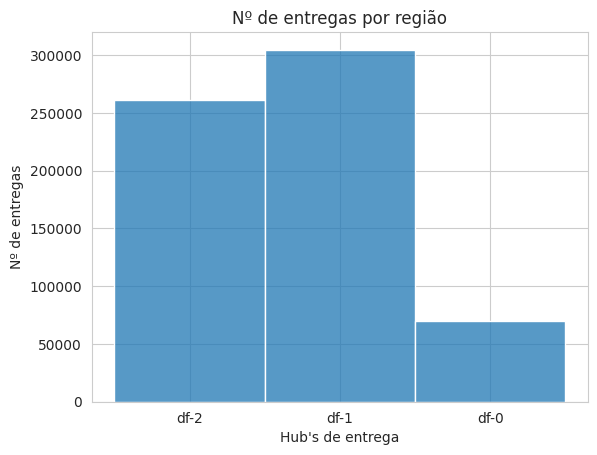

In [ ]:
deliveries_per_region_hist= deliveries_df[['region']]

with sns.axes_style('whitegrid'):
  grafico= sns.histplot(data= deliveries_df, x= 'region')
  grafico.set(title= 'Nº de entregas por região', xlabel= "Hub's de entrega", ylabel= 'Nº de entregas');

- Contexto: Endereços com maior número de entregas a serem feitas.

In [ ]:
deliveries_per_hub= deliveries_df[['delivery_lng', 'delivery_lat']].value_counts()
print(deliveries_per_hub)

delivery_lng  delivery_lat
-47.892584    -15.817557      12
-47.753464    -15.747597      10
-48.054498    -16.021173      10
-47.827307    -15.676228      10
-47.929740    -15.797443      10
                              ..
-48.023727    -15.794955       1
-47.890202    -15.811924       1
-48.023722    -15.843453       1
-47.890203    -15.752084       1
-47.931306    -15.790876       1
Length: 291566, dtype: int64
